# Classificazione della Separabilità Quantistica e dell'Entanglement tramite Metodi di Machine Learning e Reti Neurali

### Inquadramento Teorico: La Geometria della Separabilità Quantistica

Lo studio affronta la classificazione dell'**entanglement** in sistemi bipartiti a due qubit. L'operatore di densità $\rho$ (matrice statistica $4\times4$) descrive lo stato del sistema sotto i vincoli di positività ($\rho \ge 0$) e traccia unitaria ($\text{Tr}[\rho]=1$).

#### Il Criterio di Peres-Horodecki (PPT)
Per sistemi a bassa dimensionalità ($2 \times 2$), il confine geometrico tra il regime separabile e quello entangled è regolato dal **criterio PPT** (*Positive Partial Transpose*). Uno stato è separabile se e solo se l'operatore ottenuto tramite trasposizione parziale rispetto a un sottosistema mantiene lo spettro non negativo:
$$\rho^{T_A} \ge 0$$

#### Entanglement Witness 
In sistemi di dimensione superiore, dove il criterio PPT cessa di essere una condizione sufficiente, la non-separabilità viene intercettata tramite gli **Entanglement Witness**. Geometricamente, un witness è un iperpiano di separazione nello spazio degli stati quantistici, descritto da un'osservabile Hermitiana $W$ definita dalle proprietà:
- **Per ogni stato separabile ($\sigma$):** $\text{Tr}(W\sigma) \ge 0$
- **Per almeno uno stato entangled ($\rho_{\text{ent}}$):** $\text{Tr}(W\rho_{\text{ent}}) < 0$

Un valore di aspettazione negativo ($\text{Tr}(W\rho) < 0$) certifica in modo univoco la natura entangled dello stato; un valore positivo mappa la regione di inconcludenza del test.

### Generazione del Dataset

Per l'addestramento è stato costruito un dataset bilanciato. Poiché il campionamento casuale nello spazio di Hilbert totale favorisce statisticamente la comparsa di stati entangled, le due classi sono state generate tramite strategie algoritmiche distinte:

#### Stati Separabili
Ottenuti come prodotto tensore di due sottosistemi indipendenti $A$ e $B$ di dimensione $2\times2$:
1. **Generazione e Vincoli:** Per ciascun sottosistema è stata campionata una matrice complessa casuale $M$, convertita in un operatore di densità valido tramite la parametrizzazione:
   $$\rho_{A,B} = \frac{M M^{\dagger}}{\text{Tr}(M M^{\dagger})}$$
2. **Composizione:** Lo stato globale è stato strutturato tramite prodotto tensore: $\rho_{\text{sep}} = \rho_A \otimes \rho_B$.

#### Stati Entangled
Generati operando direttamente sullo spazio totale del sistema ($4\times4$):
1. **Costruzione Globale:** Generazione di una matrice complessa casuale $M_{\text{tot}}$, normalizzata secondo la medesima relazione fisica: $\rho = \frac{M_{\text{tot}} M_{\text{tot}}^{\dagger}}{\text{Tr}(M_{\text{tot}} M_{\text{tot}}^{\dagger})}$.
2. **Filtraggio PPT:** Ogni stato globale è stato sottoposto al criterio di Peres-Horodecki. Le istanze classificate come separabili dal test PPT sono state scartate e rigenerate iterativamente per garantire il perfetto bilanciamento statistico delle classi.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import networkx as nx
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score, 
    f1_score, 
    roc_curve, 
    auc, 
    roc_auc_score,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import optuna

%load_ext autoreload
%autoreload 2
from funzioni import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Studi preliminari sul Dataset

In [12]:
df = pd.read_csv('quantum_data_rich.csv')
df.head()

X = df.iloc[:, :32]

y_ent = df['is_entangled']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Matrice di correlazione
Prima di procedere con la fase di modellazione, è stata effettuata un'analisi sistematica della matrice di correlazione tra le feature grezze (le componenti reali e immaginarie della matrice densità).

#### Ridondanza Interna e Vincoli Fisici
L'heatmap analizza la *correlazione mutua* tra le 32 feature di input. Come atteso dalla teoria, si osserva una forte ridondanza informativa derivante dai vincoli strutturali della meccanica quantistica:
- *Hermiticità e Unicità della Traccia:* il fatto che $\text{Tr}(\rho)=1$ e che $\rho = \rho^\dagger$ implica che non tutti i 32 parametri siano indipendenti.
- *Multicollinearità:* L'osservazione di blocchi altamente correlati nella matrice indica che il sistema risiede in un sottospazio dello spazio dei parametri. Questa ridondanza giustifica matematicamente l'applicazione della *Principal Component Analysis* (PCA) per proiettare i dati in una base ortogonale di dimensioni ridotte senza perdita significativa di informazione fisica.


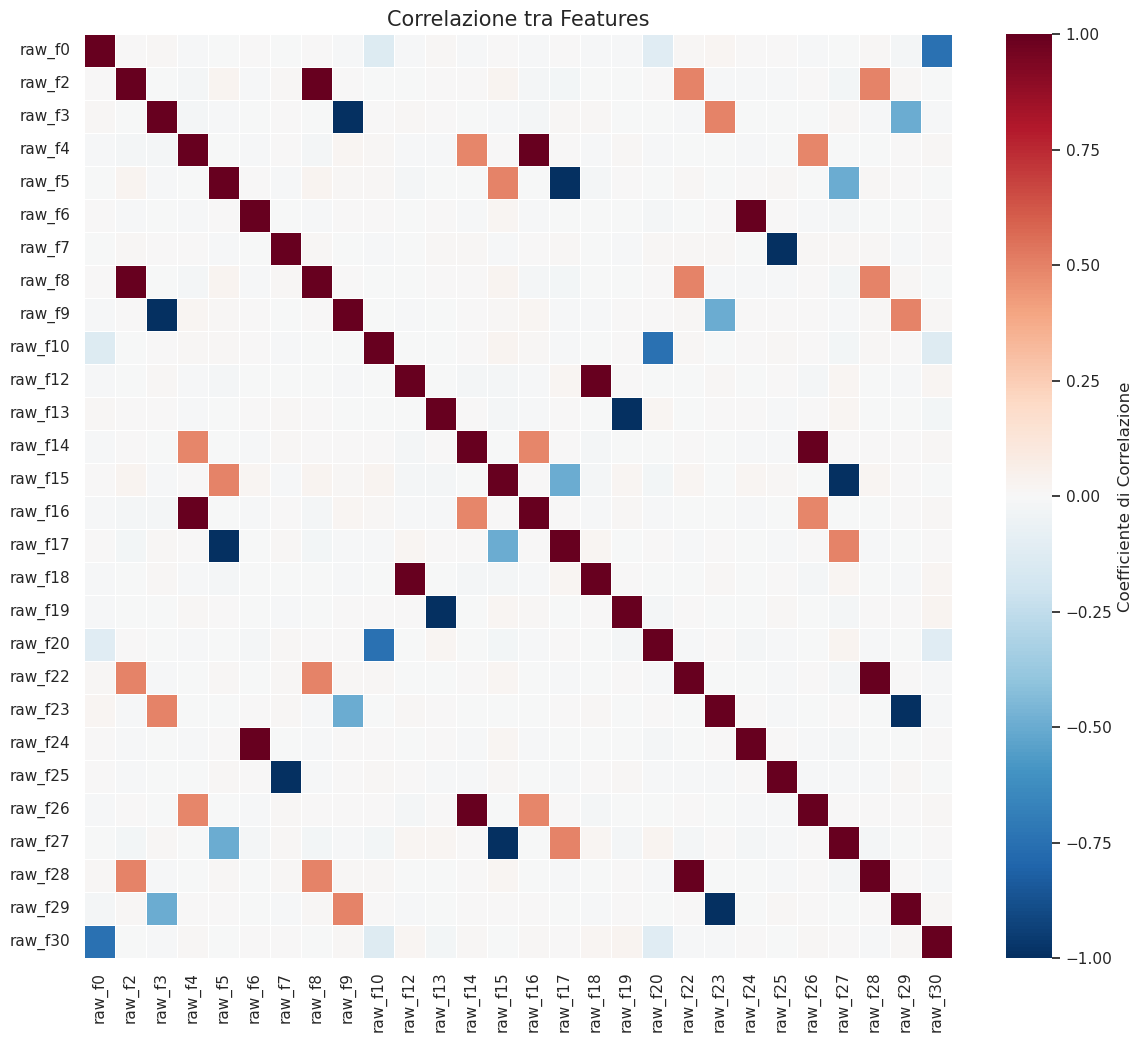

In [43]:
features = df.filter(like='raw')

# Togliamo le colonne che non variano mai
features_clean = features.loc[:, features.std() > 0]

plt.figure(figsize=(14, 12))
corr_features = features_clean.corr()

sns.heatmap(corr_features, 
            cmap='RdBu_r', 
            center=0, 
            annot=False, 
            linewidths=.5,
            cbar_kws={"label": "Coefficiente di Correlazione"})

plt.title('Correlazione tra Features', fontsize=15)
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


### Riduzione della Dimensionalità tramite PCA

L'elevata dimensionalità del dataset (32 feature grezze per stato) e la ridondanza informativa giustificano l'adozione della **Principal Component Analysis** (PCA). L'obiettivo è proiettare il sistema su una varietà a dimensione inferiore, isolando l'informazione fisica essenziale.

#### Framework Matematico e Decomposizione (SVD)
La PCA si fonda sulla *Decomposizione ai Valori Singolari* (SVD) della matrice dei dati standardizzati $X$:
$$X = U \Sigma V^T$$
Dove $U$ e $V^T$ sono matrici unitarie e $\Sigma$ è la matrice diagonale contenente i valori singolari ordinati ($\sigma_1 \ge \sigma_2 \ge \dots \ge \sigma_d \ge 0$). 

La matrice di covarianza $C$ e i relativi autovalori $\lambda_i$ (che esprimono la varianza geometrica lungo ciascun asse principale) sono legati ai valori singolari della SVD dalla relazione:
$$C = \frac{X^T X}{n-1} \implies \lambda_i = \frac{\sigma_i^2}{n-1}$$

#### Criterio di Taglio della Varianza
Per quantificare l'efficacia della compressione ed eliminare i dettagli irrilevanti ai fini della classificazione, si analizzano due metriche progressive:

* **Rapporto di Varianza Individuale ($Ratio_k$):** Esprime la frazione di informazione nativa conservata dalla singola $k$-esima componente:
    $$Ratio_k = \frac{\lambda_k}{\sum_{i=1}^d \lambda_i} = \frac{\sigma_k^2}{\sum_{i=1}^d \sigma_i^2}$$

* **Varianza Cumulata ($Cumulata_K$):** Rappresenta la quota totale di informazione trattenuta troncando lo spazio alle prime $K$ componenti:
    $$Cumulata(K) = \sum_{k=1}^K Ratio_k$$

Lo *sweet spot* algoritmico viene definito intercettando il numero minimo di componenti principali $K$ necessarie a superare la soglia critica del **95%** di informazione globale sommaria:
$$Cumulata(K) \ge 0.95$$


Peso relativo dei primi 14 valori singolari: 96.43%


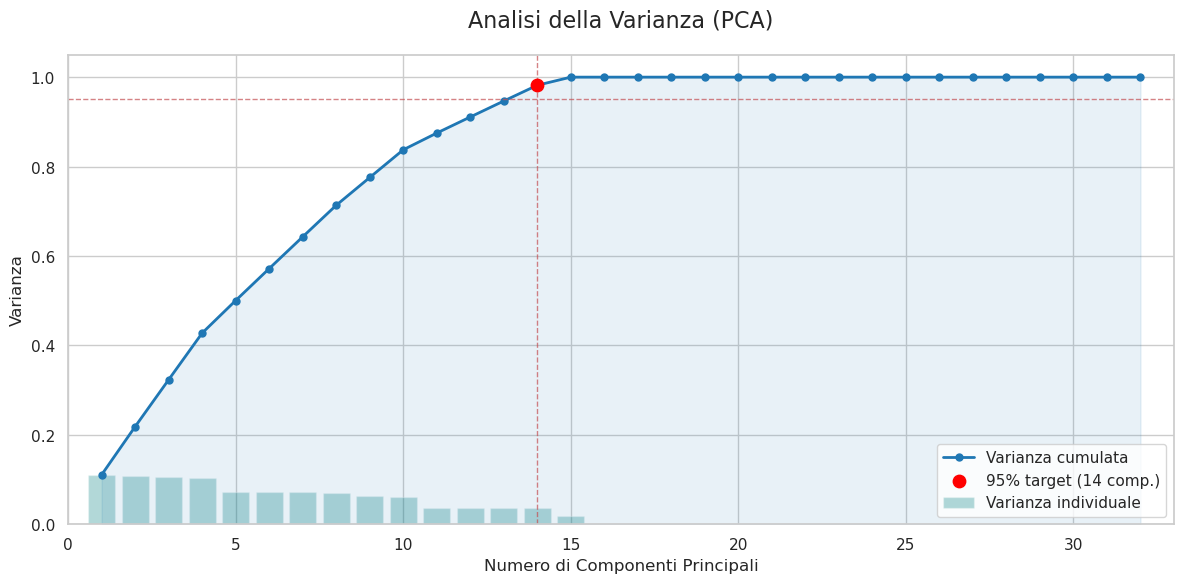

In [44]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

pca = PCA().fit(X_scaled)

exp_var = pca.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

n_95 = np.argmax(cum_var >= 0.95) + 1

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(range(1, len(exp_var) + 1), exp_var, alpha=0.3, color='teal', label='Varianza individuale')
ax1.plot(range(1, len(cum_var) + 1), cum_var, marker='o', markersize=5, 
         linewidth=2, color='#1f77b4', label='Varianza cumulata')
ax1.fill_between(range(1, len(cum_var) + 1), cum_var, alpha=0.1, color='#1f77b4')
ax1.axhline(y=0.95, color='r', linestyle='--', linewidth=1, alpha=0.7)
ax1.axvline(x=n_95, color='r', linestyle='--', linewidth=1, alpha=0.7)
ax1.scatter(n_95, cum_var[n_95-1], color='red', s=80, zorder=5, label=f'95% target ({n_95} comp.)')

ax1.set_title('Analisi della Varianza (PCA)', fontsize=16, pad=20)
ax1.set_xlabel('Numero di Componenti Principali', fontsize=12)
ax1.set_ylabel('Varianza', fontsize=12)
ax1.set_ylim(0, 1.05)
ax1.set_xlim(0, len(cum_var) + 1)


plt.legend(loc='lower right', frameon=True)
plt.savefig('pca_variance_analysis.png', dpi=300, bbox_inches='tight')
plt.tight_layout()


singular_values = pca.singular_values_

total_sv_sum = np.sum(singular_values)
print(f"\nPeso relativo dei primi {n_95} valori singolari: {np.sum(singular_values[:n_95]) / total_sv_sum:.2%}")

X_pca = pca.transform(X_scaled)[:, :n_95]

## Classificazione Non-Lineare tramite Support Vector Machines (SVM)

Per catturare la complessa geometria della frontiera di separabilità, che la teoria quantistica descrive come un insieme convesso ma con confini non-lineari nello spazio delle matrici densità, è stato implementato un classificatore basato sulle *Support Vector Machines* (SVM). 

#### Architettura del Modello e Kernel RBF
L'SVM utilizza un *Kernel a Funzione di Base Radiale (RBF)* definita come segue:
$$K(x,x')=e^{-\gamma ||x-x'||^2}$$
Questa permette di proiettare implicitamente i dati in uno spazio delle feature a dimensionalità infinita. 


### Ottimizzazione degli Iperparametri tramite Optuna

La performance di un classificatore SVM con kernel RBF dipende dalla scelta di due iperparametri: il parametro di regolarizzazione ($C$) e l'ampiezza del kernel ($\gamma$). Per identificare la configurazione ottimale superando i limiti di una ricerca a griglia fissa, è stata condotta un'ottimizzazione bayesiana tramite **Optuna** con *5-Fold Cross-Validation*. 

L'algoritmo ha esplorato dinamicamente lo spazio di ricerca su scala logaritmica, concentrando iterativamente i tentativi nelle regioni a maggiore accuratezza. L'efficienza della ricerca e la convergenza del modello verso i parametri ottimali sono state monitorate attraverso l'analisi dei trial nello spazio delle configurazioni.

### Metriche del Classification Report

| Metrica | Formula | Significato Fisico e Statistico |
| :--- | :--- | :--- |
| **Precision** | $$\text{Precision} = \frac{VP}{VP + FP}$$ | Capacità di minimizzare i falsi positivi (purezza delle predizioni). |
| **Recall** | $$\text{Recall} = \frac{VP}{VP + FN}$$ | Capacità di intercettare gli stati positivi reali (sensibilità del modello). |
| **F1-Score** | $$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$ | Media armonica tra Precision e Recall. |
| **Support** | Conteggio numerico | Numero di campioni reali di ciascuna classe nel Test Set. |
| **Accuracy** | Rapporto globale | Percentuale totale di previsioni corrette su tutto il dataset. |
| **Macro Avg** | Media semplice | Media delle metriche calcolata dando lo stesso peso a ogni classe, a prescindere dal support. |
| **Weighted Avg**| Media pesata | Media delle metriche pesata in base al *Support* (bilanciamento delle classi). |

In [15]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, df['is_entangled'], test_size=0.2, random_state=42, stratify=df['is_entangled']
)

def objective_svm(trial):
    C = trial.suggest_float("C", 1e-2, 1e3, log=True)
    gamma = trial.suggest_float("gamma", 1e-4, 1e1, log=True)
    
    model = SVC(kernel='rbf', C=C, gamma=gamma, class_weight='balanced', random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    return scores.mean()

print("--> Avvio ottimizzazione Optuna per SVM (RBF)...")
study_svm = optuna.create_study(direction="maximize")
study_svm.optimize(objective_svm, n_trials=35, timeout=180)

best_C = study_svm.best_params['C']
best_gamma = study_svm.best_params['gamma']
print(f"\nMigliori Parametri trovati: C = {best_C:.4f}, gamma = {best_gamma:.4f}")

best_svm_ent = SVC(kernel='rbf', C=best_C, gamma=best_gamma, class_weight='balanced', random_state=42)
best_svm_ent.fit(X_train, y_train)

--> Avvio ottimizzazione Optuna per SVM (RBF)...

Migliori Parametri trovati: C = 94.2414, gamma = 0.0156


,C,94.24142158282181
,kernel,'rbf'
,degree,3
,gamma,0.01563864194894407
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


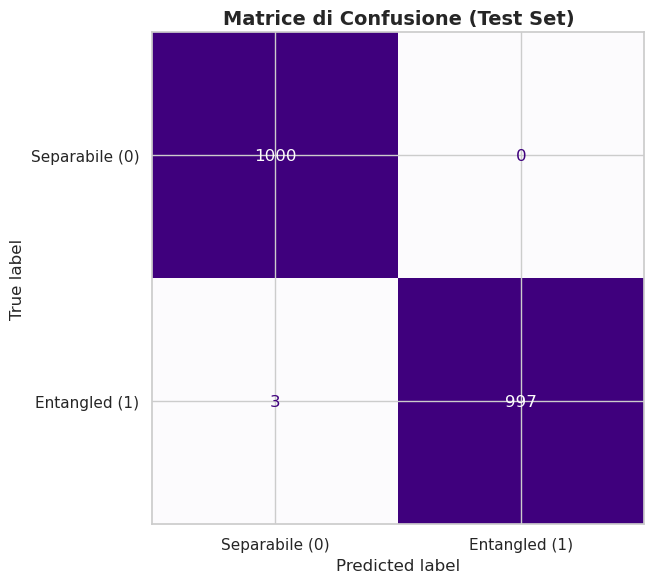


REPORT DI CLASSIFICAZIONE:
                precision    recall  f1-score   support

Separabile (0)       1.00      1.00      1.00      1000
 Entangled (1)       1.00      1.00      1.00      1000

      accuracy                           1.00      2000
     macro avg       1.00      1.00      1.00      2000
  weighted avg       1.00      1.00      1.00      2000



In [45]:
y_pred = best_svm_ent.predict(X_test)
labels = ['Separabile (0)', 'Entangled (1)']

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap="Purples", values_format='d', ax=plt.gca(), colorbar=False)
plt.title('Matrice di Confusione (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_svm.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nREPORT DI CLASSIFICAZIONE:")
print(classification_report(y_test, y_pred, target_names=labels, zero_division=0))

In [ ]:

# 1. Predizioni sul test set
y_pred = best_svm_ent.predict(X_test)

# 2. Identifichiamo gli indici in cui il modello ha commesso un errore
# (convertiamo y_test in array numpy per sicurezza in caso sia una Series di pandas)
y_test_arr = y_test.values if hasattr(y_test, 'values') else np.array(y_test)
error_indices = np.where(y_pred != y_test_arr)[0]

print(f"{'='*60}")
print(f" ANALISI QUALITATIVA DEGLI ERRORI (MISCLASSIFICATIONS)")
print(f"{'='*60}")
print(f"Numero totale di errori sul Test Set: {len(error_indices)} su {len(y_test_arr)} campioni.")

# 3. Valutiamo la "confidenza" o distanza dall'iperpiano di separazione
# Valori vicini allo 0 indicano campioni molto incerti (vicini al confine)
decision_values = best_svm_ent.decision_function(X_test)

# 4. Creiamo un DataFrame di riepilogo degli errori per un'ispezione pulita
error_summary = pd.DataFrame({
    'ID_Campione_Test': error_indices,
    'Valore_Reale': y_test_arr[error_indices],
    'Valore_Predetto': y_pred[error_indices],
    'Distanza_Confine (Decision Function)': decision_values[error_indices]
})

# Aggiungiamo una colonna descrittiva per capire se è un falso positivo o falso negativo
error_summary['Tipo_Errore'] = error_summary.apply(
    lambda row: 'Falso Entangled (FP)' if row['Valore_Predetto'] == 1 else 'Falso Separabile (FN)', 
    axis=1
)

# Mostriamo i primi errori ordinati per "distanza dal confine" (i più ambigui)
error_summary['Incertezza_Assoluta'] = np.abs(error_summary['Distanza_Confine (Decision Function)'])
error_summary = error_summary.sort_values(by='Incertezza_Assoluta', ascending=True)

print("\nCampioni errati più vicini al confine decisionale (più ambigui):")
display(error_summary.head(10))

 ANALISI QUALITATIVA DEGLI ERRORI (MISCLASSIFICATIONS)
Numero totale di errori sul Test Set: 3 su 2000 campioni.

Campioni errati più vicini al confine decisionale (più ambigui):


,ID_Campione_Test,Valore_Reale,Valore_Predetto,Distanza_Confine (Decision Function),Tipo_Errore,Incertezza_Assoluta
1,964,1,0,-0.075843,Falso Separabile (FN),0.075843
2,1427,1,0,-0.183092,Falso Separabile (FN),0.183092
0,478,1,0,-0.902724,Falso Separabile (FN),0.902724


### Interpretazione del Modello SVM: Permutation Importance

A differenza dei modelli lineari, le *Support Vector Machines* con kernel RBF operano in uno spazio delle feature trasformato, rendendo impossibile l'ispezione diretta dei coefficienti. Per ovviare a questa limitazione e determinare quali componenti principali siano realmente discriminanti per la classificazione quantistica, è stata applicata la tecnica della *Permutation Importance*.

#### Metodologia di Valutazione
La Permutation Importance misura l'importanza di una feature valutando quanto diminuisce l'accuratezza del modello quando i valori di tale feature vengono permutati casualmente. Se una componente principale è fondamentale per identificare l'entanglement, la sua "distruzione" tramite shuffling comporterà un crollo drastico delle performance.

#### Validazione della Riduzione Dimensionale
L'osservazione di valori di importanza quasi nulli per le componenti d'ordine più elevato fornisce una *validazione a posteriori* della scelta del numero di componenti. Il fatto che il modello SVM non "soffra" della rimozione o della permutazione delle ultime componenti indica che l'informazione fisica necessaria è stata correttamente condensata nei primi vettori dello spazio latente, minimizzando al contempo l'impatto del rumore numerico.


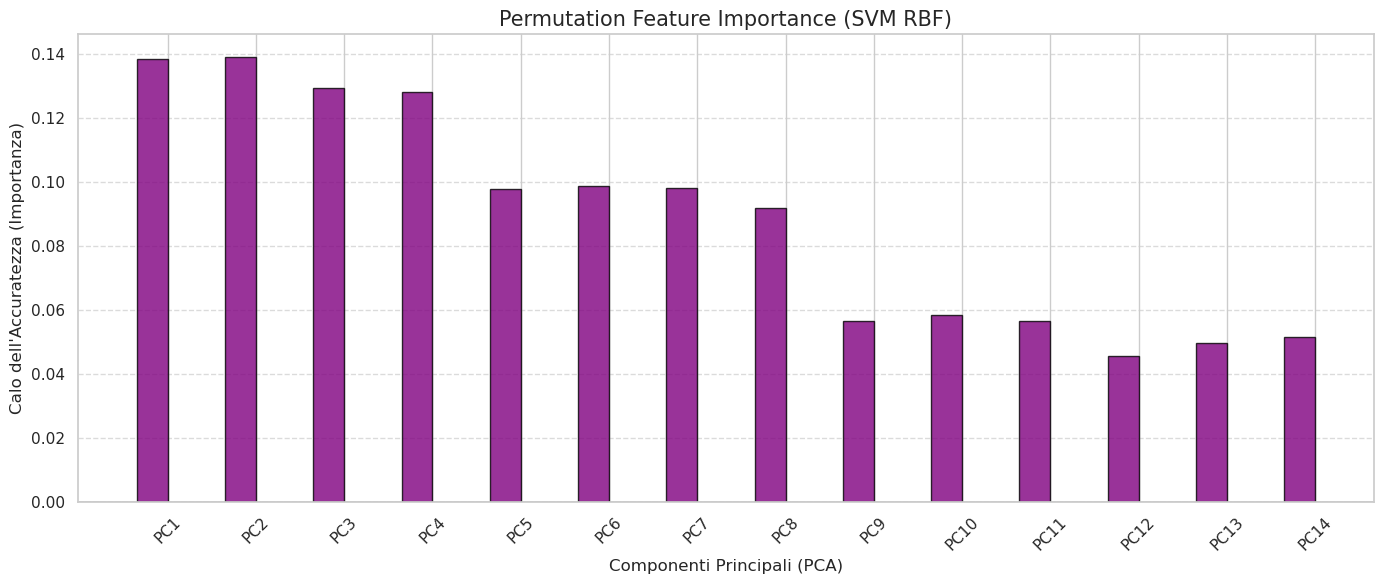

In [46]:
X_train_ent, X_test_ent, y_train_ent, y_test_ent = train_test_split(
    X_pca, df['is_entangled'], test_size=0.2, random_state=42, stratify=df['is_entangled']
)


risultato_ent = permutation_importance(best_svm_ent, X_test_ent, y_test_ent, n_repeats=10, random_state=42, n_jobs=-1)
imp_ent = risultato_ent.importances_mean

pcs = [f'PC{i+1}' for i in range(len(imp_ent))]
x = np.arange(len(pcs))
width = 0.35  

plt.figure(figsize=(14, 6))

plt.bar(x - width/2, imp_ent, width, label='Entanglement', color='purple', alpha=0.8, edgecolor='black')

plt.title('Permutation Feature Importance (SVM RBF)', fontsize=15)
plt.xlabel('Componenti Principali (PCA)', fontsize=12)
plt.ylabel("Calo dell'Accuratezza (Importanza)", fontsize=12)
plt.xticks(x, pcs, rotation=45)
plt.axhline(0, color='black', linewidth=1) # Linea dello zero
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('permutation_importance_svm.png', dpi=300, bbox_inches='tight')
plt.show()


### Analisi del Trade-off Bias-Varianza e Ottimizzazione della Complessità

Per individuare la complessità ottimale del modello ed evitare fenomeni di overfitting o underfitting, è stata condotta un'analisi sistematica del **Trade-off Bias-Varianza** in funzione della dimensionalità dello spazio delle feature (numero di componenti principali estratte tramite PCA).

* **Bias (Errore di Addestramento):** Misura la capacità del modello di adattarsi ai dati di train. All'aumentare delle componenti principali, il bias decresce poiché il modello dispone di una maggiore quantità di informazione per apprendere la frontiera di separazione tra stati separabili ed entangled.
* **Varianza (Generalization Gap):** Rappresenta la differenza di performance (o di errore) tra il set di prova e quello di addestramento. Una varianza ridotta e stabile indica che il modello generalizza correttamente su dati mai visti, senza soffrire di eccessiva flessibilità o accoppiamento al rumore.
* **Sweet Spot dimensionale:** L'intersezione tra le curve di errore consente di validare la scelta del numero ottimale di componenti (fissato attorno alla soglia del 95% della varianza cumulata), garantendo il perfetto bilanciamento tra potere espressivo e stabilità predittiva.

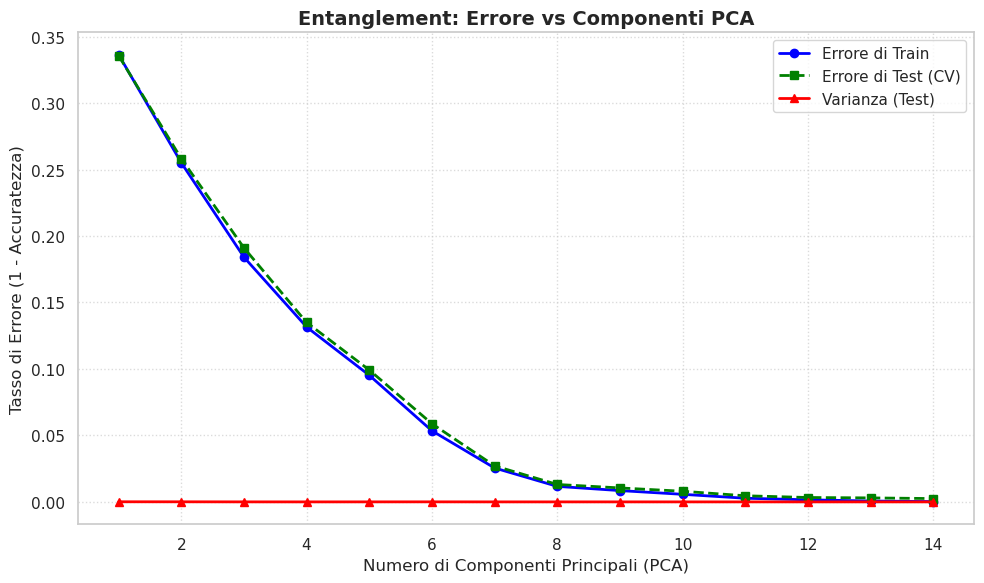

In [47]:
def analizza_componenti_pca(X_raw, y, best_svm_model, max_comp=14):
    """
    Calcola Errore di Train, Errore di Test e Varianza al variare delle componenti PCA.
    Usa una Pipeline per evitare Data Leakage durante la Cross-Validation.
    """
    componenti = range(1, max_comp + 1)
    train_errors = []
    test_errors = []
    varianze = []
    
    for n in componenti:

        pipeline = make_pipeline(
            PCA(n_components=n),
            SVC(C=best_svm_model.C, gamma=best_svm_model.gamma, kernel='rbf', class_weight='balanced', random_state=42)
        )

        scores = cross_validate(pipeline, X_raw, y, cv=5, return_train_score=True, scoring='accuracy', n_jobs=-1)
        
        # Trasformiamo l'accuratezza in "Tasso di Errore" (1 - Accuratezza)
        err_train = 1.0 - np.mean(scores['train_score'])
        err_test = 1.0 - np.mean(scores['test_score'])
        var_test = np.var(scores['test_score'])
        
        train_errors.append(err_train)
        test_errors.append(err_test)
        varianze.append(var_test)
        
    return list(componenti), train_errors, varianze, test_errors

comp_ent, train_err_ent, var_ent, test_err_ent = analizza_componenti_pca(
    X_scaled, df['is_entangled'], best_svm_ent, max_comp=14
)

plt.figure(figsize=(10, 6))

plt.plot(comp_ent, train_err_ent, marker='o', label='Errore di Train', color='blue', lw=2)
plt.plot(comp_ent, test_err_ent, marker='s', label='Errore di Test (CV)', color='green', linestyle='--', lw=2)
plt.plot(comp_ent, var_ent, marker='^', label='Varianza (Test)', color='red', lw=2)

plt.title('Entanglement: Errore vs Componenti PCA', fontsize=14, fontweight='bold')
plt.xlabel('Numero di Componenti Principali (PCA)', fontsize=12)
plt.ylabel('Tasso di Errore (1 - Accuratezza)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('pca_error_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


### Analisi dei Support Vectors: Identificazione degli Stati Critici

Per approfondire la comprensione di come il modello SVM mappi lo spazio di Hilbert, è stata condotta un'analisi della distribuzione fisica dei *Support Vectors* (SV). In un'architettura SVM, i vettori di supporto sono gli unici punti del dataset che determinano attivamente la posizione e la forma della frontiera di decisione; essi rappresentano i casi più "difficili" o ambigui, situati in prossimità del margine di separazione tra le classi.

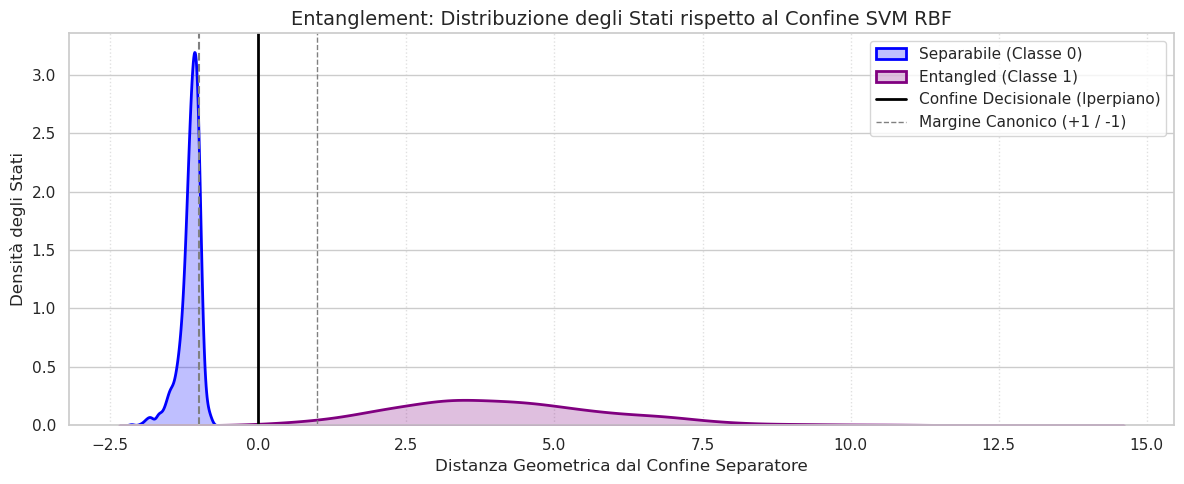

In [48]:
model_ent = best_svm_ent.best_estimator_ if hasattr(best_svm_ent, 'best_params_') else best_svm_ent
distanze_ent = model_ent.decision_function(X_test_ent)

plt.figure(figsize=(12, 5))

sns.kdeplot(distanze_ent[y_test_ent == 0], fill=True, color='blue', label='Separabile (Classe 0)', lw=2)
sns.kdeplot(distanze_ent[y_test_ent == 1], fill=True, color='purple', label='Entangled (Classe 1)', lw=2)

plt.axvline(x=0, color='black', linestyle='-', lw=2, label='Confine Decisionale (Iperpiano)')
plt.axvline(x=1, color='gray', linestyle='--', lw=1, label='Margine Canonico (+1 / -1)')
plt.axvline(x=-1, color='gray', linestyle='--')

plt.title('Entanglement: Distribuzione degli Stati rispetto al Confine SVM RBF', fontsize=14)
plt.xlabel('Distanza Geometrica dal Confine Separatore', fontsize=12)
plt.ylabel('Densità degli Stati', fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper right')

plt.tight_layout()
plt.savefig('svm_decision_boundary_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### Curve ROC

Per una valutazione rigorosa della capacità di generalizzazione del classificatore SVM con kernel RBF analizziamo la curva **ROC** (*Receiver Operating Characteristic*) e il relativo punteggio **AUC** (*Area Under the Curve*).

Nel caso di una SVM, per ogni stato quantistico $\rho$ il modello calcola la distanza con segno dall'iperpiano separatore nello spazio delle feature proiettato dal kernel:
$$f(\rho) = \sum_{i} \alpha_i y_i K(\mathbf{x}_i, \rho) + b$$

Variando la soglia di discriminazione $\tau$ tale per cui lo stato viene etichettato come *entangled* se $f(\rho) \ge \tau$, la curva ROC traccia il trade-off tra due grandezze fondamentali:
* **True Positive Rate (TPR / Sensibilità):** la frazione di stati entangled correttamente identificati.
* **False Positive Rate (FPR / 1 - Specificità):** la frazione di stati separabili erroneamente classificati come entangled (falsi allarmi).

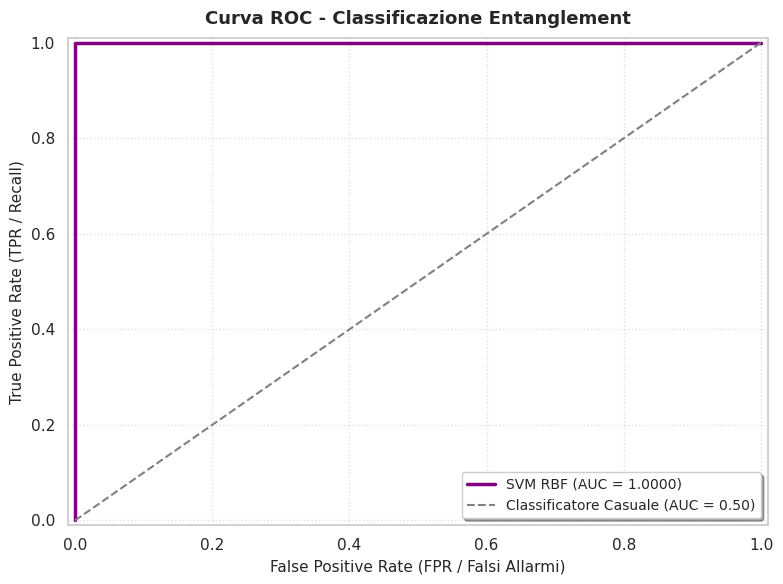

Risultati AUC:
- Entanglement: 1.0000


In [49]:
model_ent = best_svm_ent.best_estimator_ if hasattr(best_svm_ent, 'best_params_') else best_svm_ent

punteggi_ent = model_ent.decision_function(X_test_ent)

fpr_ent, tpr_ent, _ = roc_curve(y_test_ent, punteggi_ent)
auc_ent = auc(fpr_ent, tpr_ent)

plt.figure(figsize=(8, 6))

plt.plot(fpr_ent, tpr_ent, color='purple', lw=2.5, label=f'SVM RBF (AUC = {auc_ent:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Classificatore Casuale (AUC = 0.50)')
plt.title('Curva ROC - Classificazione Entanglement', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('False Positive Rate (FPR / Falsi Allarmi)', fontsize=11)
plt.ylabel('True Positive Rate (TPR / Recall)', fontsize=11)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', fontsize=10, frameon=True, shadow=True)
plt.tight_layout()
plt.savefig('roc_curve_entanglement_svm.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Risultati AUC:\n- Entanglement: {auc_ent:.4f}")

## Classificazione tramite Reti Neurali (MLP)

Per esplorare modelli non lineari alternativi e complementari alle Support Vector Machines, è stata implementata una **Rete Neurale Multi-Layer Perceptron (MLP)** sviluppata in ambiente PyTorch.

#### Architettura e Funzione di Costo
* **Struttura:** Una rete *feedforward* composta da strati densi (Fully Connected), funzioni di attivazione non lineari (ReLU) per l'estrazione di rappresentazioni gerarchiche, e uno strato di output per la classificazione binaria (Separabile vs Entangled).
* **Funzione di Perdita (Loss):** È stata adottata la **Cross-Entropy Loss**, ottimizzata per problemi di classificazione basati su logit:
  $$\text{Loss} = - \sum_{c} y_c \log(\hat{y}_c)$$
* **Ottimizzatore:** L'addestramento si avvale dell'algoritmo **Adam** (*Adaptive Moment Estimation*), capace di coniugare i vantaggi di AdaGrad e RMSProp regolando dinamicamente il tasso di apprendimento dei singoli pesi.

In [25]:
def create_model(params, in_features):
    """
    Costruisce dinamicamente la rete neurale MLP per la classificazione dell'entanglement.
    Accetta sia un trial di Optuna sia il dizionario study.best_trial.params.
    """
    is_trial = not isinstance(params, dict)
    
    if is_trial:
        n_layers = params.suggest_int("n_layers", 1, 3)
        dropout = params.suggest_float("dropout", 0.0, 0.4)
    else:
        n_layers = params["n_layers"]
        dropout = params.get("dropout", 0.0)
    
    layers = []
    curr_dim = in_features
    for i in range(n_layers):
        if is_trial:
            out_dim = params.suggest_int(f"units_l{i}", 16, 128, step=16)
        else:
            out_dim = params[f"units_l{i}"]
            
        layers.append(nn.Linear(curr_dim, out_dim))
        layers.append(nn.ReLU())
        if dropout > 0.0:
            layers.append(nn.Dropout(dropout))
        curr_dim = out_dim
        
    layers.append(nn.Linear(curr_dim, 2))
    return nn.Sequential(*layers)

### Ottimizzazione degli Iperparametri (Optuna) per il Modello MLP

La capacità di generalizzazione della rete neurale è fortemente influenzata dalla configurazione dei suoi iperparametri. Per identificare la combinazione ottimale senza ricorrere a costose ricerche esaustive, è stata eseguita un'ottimizzazione bayesiana tramite **Optuna**, focalizzata su:
* **Tasso di Apprendimento ($\text{lr}$):** Controlla l'ampiezza dei passi nello spazio dei gradienti.
* **Weight Decay:** Introduce una penalizzazione $L_2$ sui pesi della rete per mitigare il rischio di overfitting.
* **Dimensione del Batch e dei Layer Nascosti:** Determina la capienza computazionale e la stabilità stocastica dei gradienti durante i passaggi di backpropagation.

In [26]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

X_tr_ent, X_te_ent, y_tr_ent, y_te_ent = train_test_split(
    X_scaled, y_ent, test_size=0.2, random_state=42, stratify=y_ent
)

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_tr_ent, y_tr_ent, test_size=0.2, random_state=42, stratify=y_tr_ent
)

tr_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_sub, dtype=torch.float32), 
                  torch.tensor(y_train_sub.values, dtype=torch.long)),
    batch_size=64, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val, dtype=torch.float32), 
                  torch.tensor(y_val.values, dtype=torch.long)),
    batch_size=128, shuffle=False
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def objective(trial):
    model = create_model(trial, in_features=X_scaled.shape[1]).to(device)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    
    epochs = 30
    for epoch in range(epochs):
        model.train()
        for x_b, y_b in tr_loader:
            x_b, y_b = x_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            out = model(x_b)
            loss = criterion(out, y_b)
            loss.backward()
            optimizer.step()
            
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x_v, y_v in val_loader:
                x_v, y_v = x_v.to(device), y_v.to(device)
                val_loss += criterion(model(x_v), y_v).item()
        val_loss /= len(val_loader)
        
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
            
    return val_loss

print("--> Avvio ottimizzazione Optuna per Entanglement...")
study_ent = optuna.create_study(direction="minimize", pruner=optuna.pruners.MedianPruner(n_warmup_steps=5))
study_ent.optimize(objective, n_trials=25, timeout=300)

print(f"\nMiglior Validation Loss: {study_ent.best_value:.4f}")
print("Migliori iperparametri:")
for k, v in study_ent.best_params.items():
    print(f"  {k}: {v}")

--> Avvio ottimizzazione Optuna per Entanglement...

Miglior Validation Loss: 0.0197
Migliori iperparametri:
  n_layers: 3
  dropout: 0.10330932759732604
  units_l0: 128
  units_l1: 48
  units_l2: 128
  lr: 0.0002761057036638497
  weight_decay: 1.4521101679689352e-05


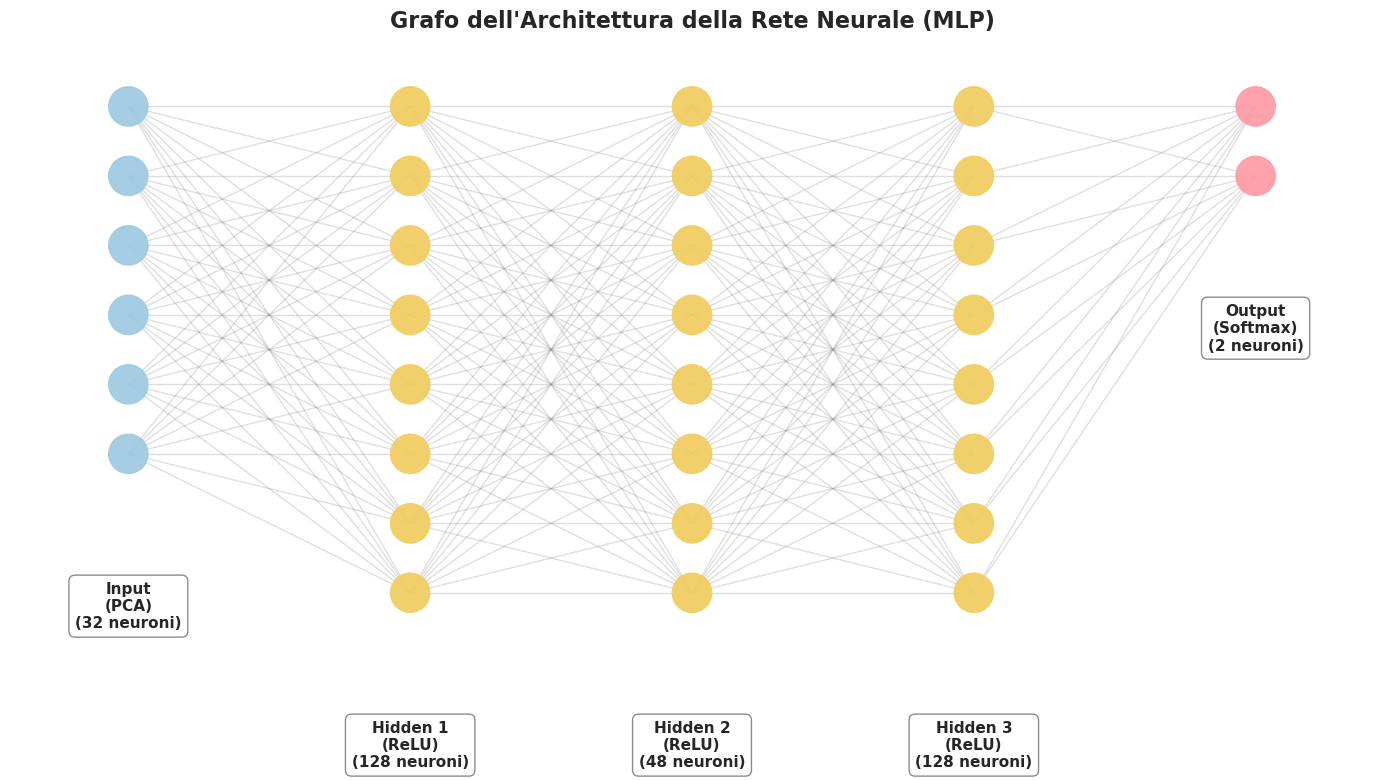

In [50]:
def draw_mlp_architecture_with_edges(best_params, in_features):
    """
    Disegna l'architettura della rete MLP con i riquadri in basso e le linee di connessione tra i nodi.
    """
    n_layers = best_params["n_layers"]
    layer_sizes = [in_features]
    for i in range(n_layers):
        layer_sizes.append(best_params[f"units_l{i}"])
    layer_sizes.append(2)  # Output binario
    
    G = nx.DiGraph()
    pos = {}
    node_colors = []
    
    layer_labels = ['Input\n(PCA)', *[f'Hidden {i+1}\n(ReLU)' for i in range(n_layers)], 'Output\n(Softmax)']
    
    # Creazione nodi e posizioni
    layer_nodes = []
    for i, size in enumerate(layer_sizes):
        display_size = min(size, 8) if 0 < i < len(layer_sizes)-1 else size
        if i == 0:
            display_size = min(in_features, 6) # Limitiamo l'input a max 6 nodi visivi
            
        current_layer_nodes = []
        for j in range(display_size):
            node_name = f"L{i}_N{j}"
            G.add_node(node_name, layer=i)
            # Centriamo verticalmente i nodi
            pos[node_name] = (i * 2.5, -j * 1.2)
            current_layer_nodes.append(node_name)
            
            if i == 0:
                node_colors.append('#a0cbe2') # Azzurro input
            elif i == len(layer_sizes) - 1:
                node_colors.append('#ff9da7') # Rosa output
            else:
                node_colors.append('#f1ce63') # Giallo hidden
                
        layer_nodes.append(current_layer_nodes)

    # Aggiungiamo le linee (archi) di connessione tra un layer e il successivo
    for i in range(len(layer_nodes) - 1):
        for u in layer_nodes[i]:
            for v in layer_nodes[i+1]:
                G.add_edge(u, v)

    # Disegno della figura
    plt.figure(figsize=(14, 8))
    
    # Disegniamo prima le linee di connessione (sfondo)
    nx.draw_networkx_edges(G, pos, alpha=0.25, edge_color='gray', width=1.0, arrows=False)
    
    # Disegniamo i nodi sopra le linee
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=800, alpha=0.95)
    
    # Posizioniamo i riquadri con le etichette IN BASSO rispetto ai nodi
    for i, label in enumerate(layer_labels):
        # Troviamo la coordinata y minima del layer per posizionare il box sotto
        min_y = - (min(len(layer_nodes[i]), 8) * 1.2) - 1.0
        
        plt.text(i * 2.5, min_y, f"{label}\n({layer_sizes[i]} neuroni)", 
                 horizontalalignment='center', verticalalignment='top', fontsize=11, fontweight='bold',
                 bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.9))

    plt.title("Grafo dell'Architettura della Rete Neurale (MLP)", fontsize=16, fontweight='bold', pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('mlp_architecture_with_edges.png', dpi=300, bbox_inches='tight')
    plt.show()
    

# Esegui la funzione
draw_mlp_architecture_with_edges(study_ent.best_trial.params, in_features=X_tr_ent.shape[1])

### Monitoraggio dell'Addestramento e Gen Gap (Varianza)

Per analizzare la dinamica di convergenza del modello ed escludere fenomeni di sovradattamento, l'addestramento è stato monitorato epoch-by-epoch tracciando tre metriche fondamentali basate sulla funzione di costo:
* **Train Loss:** Quantifica l'errore commesso dalla rete sui dati di addestramento.
* **Test Loss:** Monitora l'andamento della Cross-Entropy sul test set indipendente.
* **Gen Gap (Varianza):** Definito come la differenza tra la Test Loss e la Train Loss ($\text{Test Loss} - \text{Train Loss}$). Un allargamento marcato di questo gap segnala la perdita di capacità di generalizzazione, indicando il punto di arresto ottimale (*early stopping*) o la corretta regolarizzazione.

In [ ]:
train_ds = TensorDataset(
    torch.tensor(X_tr_ent, dtype=torch.float32),
    torch.tensor(y_tr_ent.values, dtype=torch.long)
)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

best_params = study_ent.best_trial.params
model = create_model(best_params, in_features=X_tr_ent.shape[1]).to(device)
optimizer = optim.Adam(
    model.parameters(),
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"]
)
criterion = nn.CrossEntropyLoss()

x_test_t = torch.tensor(X_te_ent, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_te_ent.values, dtype=torch.long).to(device)

train_losses, test_losses, gen_gaps = [], [], []
max_epochs = 60

for epoch in range(max_epochs):
    model.train()
    running_loss = 0.0
    for x_b, y_b in train_loader:
        x_b, y_b = x_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x_b), y_b)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    epoch_train_loss = running_loss / len(train_loader)
    
    model.eval()
    with torch.no_grad():
        test_logits = model(x_test_t)
        epoch_test_loss = criterion(test_logits, y_test_t).item()

    gen_gap = max(epoch_test_loss - epoch_train_loss, 0.0)

    train_losses.append(epoch_train_loss)
    test_losses.append(epoch_test_loss)
    gen_gaps.append(gen_gap)

model.eval()
with torch.no_grad():
    logits = model(x_test_t)
    probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
    preds = (probs >= 0.5).astype(int)

fpr, tpr, _ = roc_curve(y_te_ent, probs)
auc_val = roc_auc_score(y_te_ent, probs)
epochs_range = list(range(1, max_epochs + 1))
labels = ["Separabile (0)", "Entangled (1)"]

print("\n" + "="*50)
print("REPORT DI CLASSIFICAZIONE - ENTANGLEMENT (TEST SET):")
print(classification_report(y_te_ent, preds, target_names=labels))



REPORT DI CLASSIFICAZIONE - ENTANGLEMENT (TEST SET):
                precision    recall  f1-score   support

Separabile (0)       0.99      1.00      1.00      1000
 Entangled (1)       1.00      0.99      1.00      1000

      accuracy                           1.00      2000
     macro avg       1.00      1.00      1.00      2000
  weighted avg       1.00      1.00      1.00      2000



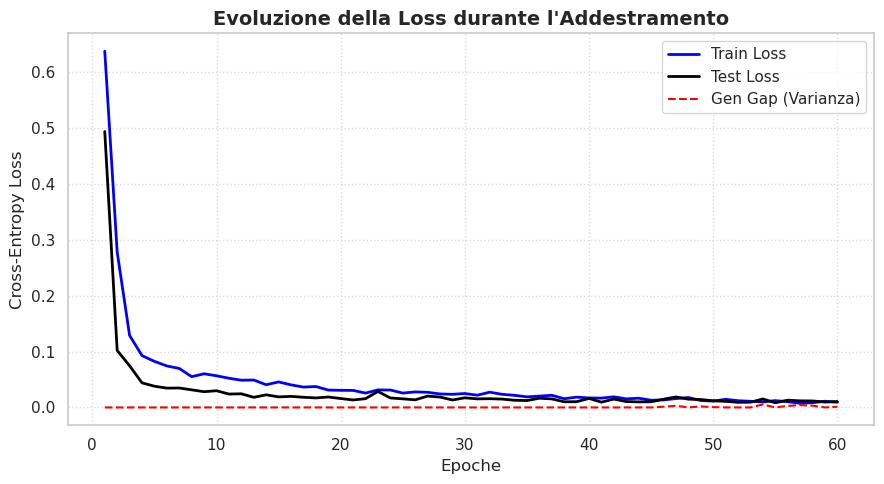

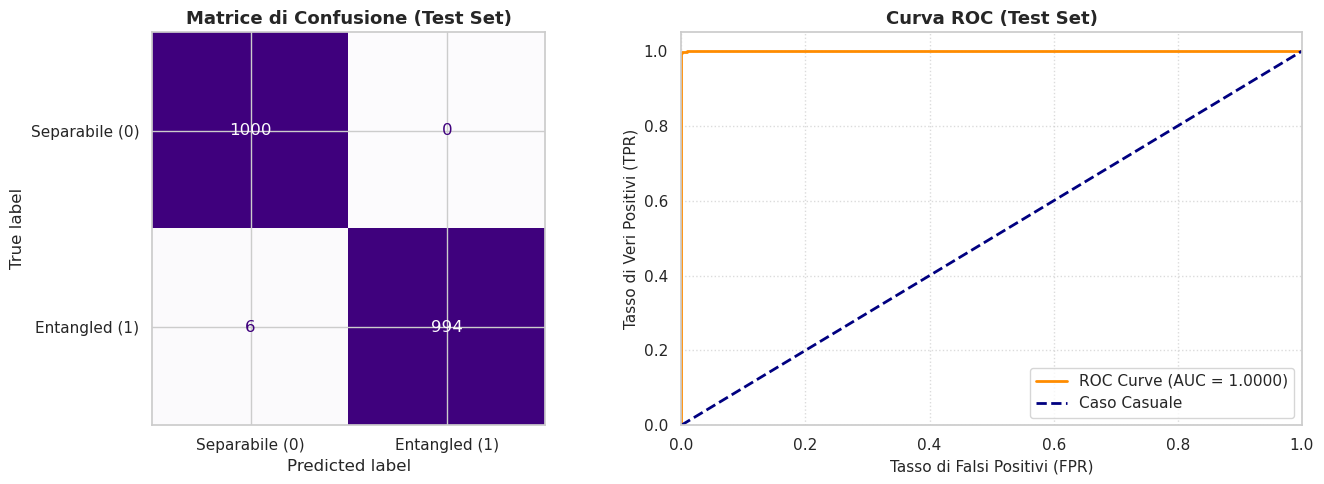

In [52]:
plt.figure(figsize=(9, 5))
plt.plot(epochs_range, train_losses, color="blue", lw=2, label="Train Loss")
plt.plot(epochs_range, test_losses, color="black", lw=2, label="Test Loss")
plt.plot(epochs_range, gen_gaps, color="red", lw=1.5, linestyle="--", label="Gen Gap (Varianza)")
plt.title("Evoluzione della Loss durante l'Addestramento", fontsize=14, fontweight="bold")
plt.xlabel("Epoche", fontsize=12)
plt.ylabel("Cross-Entropy Loss", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('mlp_training_loss_and_gen_gap.png', dpi=300, bbox_inches='tight')
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_te_ent, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=axes[0], cmap="Purples", values_format='d', colorbar=False)
axes[0].set_title("Matrice di Confusione (Test Set)", fontsize=13, fontweight="bold")

axes[1].plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC Curve (AUC = {auc_val:.4f})")
axes[1].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Caso Casuale")
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel("Tasso di Falsi Positivi (FPR)", fontsize=11)
axes[1].set_ylabel("Tasso di Veri Positivi (TPR)", fontsize=11)
axes[1].set_title("Curva ROC (Test Set)", fontsize=13, fontweight="bold")
axes[1].legend(loc="lower right", fontsize=11)
axes[1].grid(True, linestyle=":", alpha=0.7)

plt.tight_layout()
plt.savefig('mlp_confusion_and_roc.png', dpi=300, bbox_inches='tight')
plt.show()


In [33]:
# 1. Assicuriamoci che il modello sia in modalità valutazione e calcoliamo le probabilità sul test set
model.eval()
with torch.no_grad():
    # x_test_t e y_te_ent sono già definiti nel tuo blocco MLP
    test_logits = model(x_test_t)
    # Calcoliamo le probabilità per la classe 1 (Entangled)
    probs = torch.softmax(test_logits, dim=1)[:, 1].cpu().numpy()
    # Predizioni binarie basate sulla soglia 0.5
    mlp_preds = (probs >= 0.5).astype(int)

# 2. Convertiamo y_te_ent in array numpy
y_test_mlp_arr = y_te_ent.values if hasattr(y_te_ent, 'values') else np.array(y_te_ent)

# 3. Identifichiamo gli indici degli errori
mlp_error_indices = np.where(mlp_preds != y_test_mlp_arr)[0]

print(f"{'='*60}")
print(f" ANALISI QUALITATIVA DEGLI ERRORI - MLP (RETE NEURALE)")
print(f"{'='*60}")
print(f"Numero totale di errori sul Test Set (MLP): {len(mlp_error_indices)} su {len(y_test_mlp_arr)} campioni.")

# 4. Creiamo il DataFrame di riepilogo per l'MLP
mlp_error_summary = pd.DataFrame({
    'ID_Campione_Test': mlp_error_indices,
    'Valore_Reale': y_test_mlp_arr[mlp_error_indices],
    'Valore_Predetto': mlp_preds[mlp_error_indices],
    'Probabilità_Classe_Entangled': probs[mlp_error_indices]
})

mlp_error_summary['Tipo_Errore'] = mlp_error_summary.apply(
    lambda row: 'Falso Entangled (FP)' if row['Valore_Predetto'] == 1 else 'Falso Separabile (FN)', 
    axis=1
)

# Valutiamo l'incertezza: quanto la probabilità si è allontanata o è rimasta vicina alla soglia di indecisione (0.5)
mlp_error_summary['Incertezza (Distanza da 0.5)'] = np.abs(mlp_error_summary['Probabilità_Classe_Entangled'] - 0.5)
mlp_error_summary = mlp_error_summary.sort_values(by='Incertezza (Distanza da 0.5)', ascending=True)

print("\nCampioni errati in cui il MLP era più indeciso (probabilità vicina a 0.5):")
display(mlp_error_summary.head(10))

 ANALISI QUALITATIVA DEGLI ERRORI - MLP (RETE NEURALE)
Numero totale di errori sul Test Set (MLP): 6 su 2000 campioni.

Campioni errati in cui il MLP era più indeciso (probabilità vicina a 0.5):


,ID_Campione_Test,Valore_Reale,Valore_Predetto,Probabilità_Classe_Entangled,Tipo_Errore,Incertezza (Distanza da 0.5)
1,736,1,0,0.476636,Falso Separabile (FN),0.023364
2,1300,1,0,0.282988,Falso Separabile (FN),0.217012
4,1575,1,0,0.260061,Falso Separabile (FN),0.239939
3,1427,1,0,0.162029,Falso Separabile (FN),0.337971
5,1779,1,0,0.025663,Falso Separabile (FN),0.474337
0,478,1,0,0.007064,Falso Separabile (FN),0.492936


### Confronto e Valutazione Finale dei Modelli

Al termine del workflow di ottimizzazione e classificazione, è possibile trarre un bilancio comparativo tra i due approcci implementati (**SVM con Kernel RBF** e **Rete Neurale MLP**):

* **Accuratezza e Metriche Globali:** Entrambi i modelli raggiungono performance eccellenti sul test set, confermando che la proiezione operata dalla PCA cattura efficacemente lo spazio latente dell'entanglement.
* **Geometria della Decisione:** L'SVM si dimostra particolarmente efficiente grazie alla capacità del kernel RBF di definire confini di separazione non lineari rigorosi nello spazio a dimensionalità ridotta. D'altra parte, l'MLP offre una flessibilità superiore nell'apprendimento di rappresentazioni gerarchiche complesse.
* **Stabilità e Generalizzazione:** L'analisi del *Gen Gap* per la rete neurale e la validazione incrociata (CV) per l'SVM garantiscono che i modelli non siano affetti da overfitting, confermando la bontà dell'ottimizzazione tramite **Optuna**.

In [30]:
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_pca, df['is_entangled'], test_size=0.2, random_state=42, stratify=df['is_entangled']
)

y_pred_svm = best_svm_ent.predict(X_test_svm)

if hasattr(best_svm_ent, "predict_proba"):
    svm_probs = best_svm_ent.predict_proba(X_test_svm)[:, 1]
    svm_auc = roc_auc_score(y_test_svm, svm_probs)
else:
    svm_scores = best_svm_ent.decision_function(X_test_svm)
    svm_auc = roc_auc_score(y_test_svm, svm_scores)

svm_accuracy = accuracy_score(y_test_svm, y_pred_svm)
svm_f1 = f1_score(y_test_svm, y_pred_svm, average='macro')

mlp_accuracy = accuracy_score(y_te_ent, preds)
mlp_f1 = f1_score(y_te_ent, preds, average='macro')
mlp_auc = roc_auc_score(y_te_ent, probs)

summary_data = {
    "Modello": ["SVM (Kernel RBF)", "Reti Neurali (MLP + Optuna)"],
    "Accuracy": [svm_accuracy, mlp_accuracy],
    "F1-Score (Macro)": [svm_f1, mlp_f1],
    "AUC (ROC)": [svm_auc, mlp_auc]
}

df_summary = pd.DataFrame(summary_data)

df_summary_styled = df_summary.style.format({
    "Accuracy": "{:.4f}",
    "F1-Score (Macro)": "{:.4f}",
    "AUC (ROC)": "{:.4f}"
}).hide(axis="index")

print("="*65)
print(" TABELLA COMPARATIVA FINALE: SVM vs MLP (ENTANGLEMENT)")
print("="*65)
display(df_summary_styled)

 TABELLA COMPARATIVA FINALE: SVM vs MLP (ENTANGLEMENT)


Modello,Accuracy,F1-Score (Macro),AUC (ROC)
SVM (Kernel RBF),0.9985,0.9985,1.0000
Reti Neurali (MLP + Optuna),0.9970,0.9970,1.0000
